In [2]:
import pandas as pd

df = pd.read_csv("news.csv")
df.head()


,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


In [3]:
df['headline_length'] = df['headline'].astype(str).apply(len)
df['headline_length'].describe()


count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_length, dtype: float64

In [4]:
df['publisher'].value_counts()


publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
                      ...  
MoneyGeek                 1
muathe                    1
Robert Morris             1
LeftCoastHedgie           1
Jeremie Capron            1
Name: count, Length: 1034, dtype: int64

<Axes: xlabel='date'>

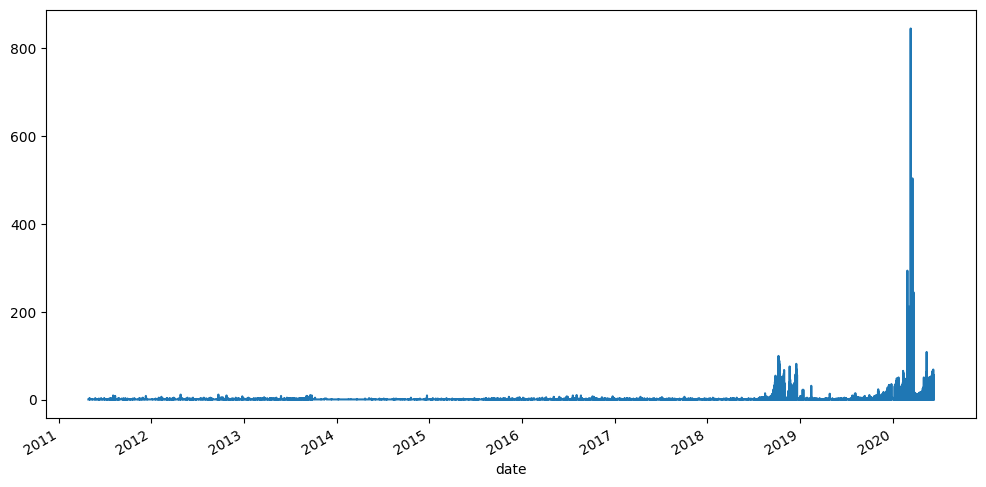

In [6]:
df['date'] = pd.to_datetime(df['date'], errors='coerce', utc=True)

df['date'].value_counts().sort_index().plot(figsize=(12,6))


   Unnamed: 0                                           headline  \
0           0            Stocks That Hit 52-Week Highs On Friday   
1           1         Stocks That Hit 52-Week Highs On Wednesday   
2           2                      71 Biggest Movers From Friday   
3           3       46 Stocks Moving In Friday's Mid-Day Session   
4           4  B of A Securities Maintains Neutral on Agilent...   

                                                 url          publisher  \
0  https://www.benzinga.com/news/20/06/16190091/s...  Benzinga Insights   
1  https://www.benzinga.com/news/20/06/16170189/s...  Benzinga Insights   
2  https://www.benzinga.com/news/20/05/16103463/7...         Lisa Levin   
3  https://www.benzinga.com/news/20/05/16095921/4...         Lisa Levin   
4  https://www.benzinga.com/news/20/05/16095304/b...         Vick Meyer   

                        date stock  
0  2020-06-05 10:30:54-04:00     A  
1  2020-06-03 10:45:20-04:00     A  
2  2020-05-26 04:30:07-04:00 

[nltk_data] Downloading package stopwords to C:\Users\Asus
[nltk_data]     vivobook\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


0                       stocks hit 52week highs friday
1                    stocks hit 52week highs wednesday
2                             71 biggest movers friday
3              46 stocks moving fridays midday session
4    b securities maintains neutral agilent technol...
Name: clean_text, dtype: object
DTM shape: (1407328, 3000)


<Axes: xlabel='hour'>

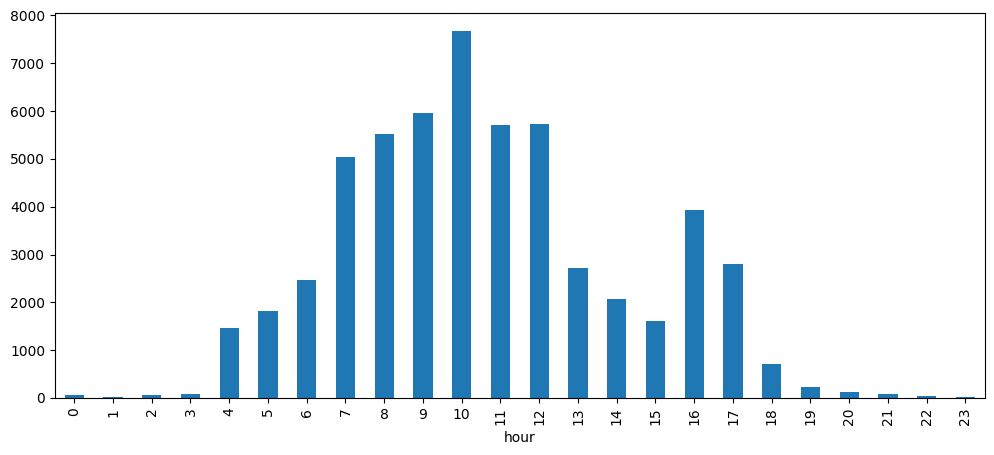

In [1]:
import pandas as pd

# Load your dataset
df = pd.read_csv("news.csv")   # <-- change to your real file name
print(df.head())
import pandas as pd
df = pd.read_csv("news.csv")   # change file name
df.head()
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

stop_words = stopwords.words('english')

df['clean_text'] = (
    df['headline']
    .astype(str)
    .str.lower()
    .str.replace(r'[^\w\s]', '', regex=True)
    .apply(lambda x: " ".join([word for word in x.split() if word not in stop_words]))
)

print(df['clean_text'].head())
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(max_features=3000)
dtm = cv.fit_transform(df['clean_text'])

print("DTM shape:", dtm.shape)

    
df['date'].head(10)
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['date'].dtypes
df['date'].isna().sum()
df = df.dropna(subset=['date'])
df.groupby(df['date'].dt.date).size().plot(figsize=(12,5))
df['hour'] = df['date'].dt.hour
df['hour'].value_counts().sort_index().plot(kind='bar', figsize=(12,5))







In [ ]:
import pandas as pd
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
df = pd.read_csv("news.csv")
nltk.download('stopwords')
stop_words = stopwords.words('english')

df['clean_text'] = (
    df['headline']
    .astype(str)
    .str.lower()
    .str.replace(r'[^\w\s]', '', regex=True)
    .apply(lambda x: " ".join([word for word in x.split() if word not in stop_words]))
)
cv = CountVectorizer(max_features=3000)
dtm = cv.fit_transform(df['clean_text'])

print("DTM shape:", dtm.shape)
lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(dtm)

print("LDA trained successfully!")
df['topic'] = lda.transform(dtm).argmax(axis=1)
df['publisher'].value_counts().head(10)
df['topic'] = lda.transform(dtm).argmax(axis=1)
df.groupby(['publisher', 'topic']).size()
df['publisher_domain'] = df['publisher'].str.extract(r'@(.+)')
df['publisher_domain'].value_counts()


[nltk_data] Downloading package stopwords to C:\Users\Asus
[nltk_data]     vivobook\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


DTM shape: (1407328, 3000)
